<a href="https://colab.research.google.com/github/sathana495/ML-project/blob/main/AI_job_market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
path='/content/drive/MyDrive/dataset/AI_Job_Market_Trends_2026.csv'
df=pd.read_csv(path)
df.head()

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


In [ ]:
df.shape

(10345, 19)

In [ ]:
df.tail()

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
10340,10341,Data Engineer,Startup,Technology,USA,Onsite,Entry,2,PhD,1,0,1,0,1,76426,4,2023,Low,4
10341,10342,Data Analyst,Medium,Healthcare,Australia,Hybrid,Entry,10,Master,1,1,0,0,1,61233,9,2024,Medium,6
10342,10343,Machine Learning Engineer,Startup,Education,Germany,Hybrid,Entry,4,PhD,0,0,0,1,0,103681,3,2026,Low,4
10343,10344,Data Engineer,MNC,E-commerce,Canada,Hybrid,Mid,5,PhD,1,1,1,0,0,112895,12,2024,High,9
10344,10345,AI Engineer,Startup,Education,Australia,Onsite,Mid,12,PhD,0,1,1,1,1,159570,11,2022,High,3


In [ ]:
df = df.drop(columns=['job_id'])
df.head()

,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


In [ ]:
df.isna().sum()

,0
job_title,0
company_size,0
company_industry,0
country,0
remote_type,0
experience_level,0
years_experience,0
education_level,0
skills_python,0
skills_sql,0


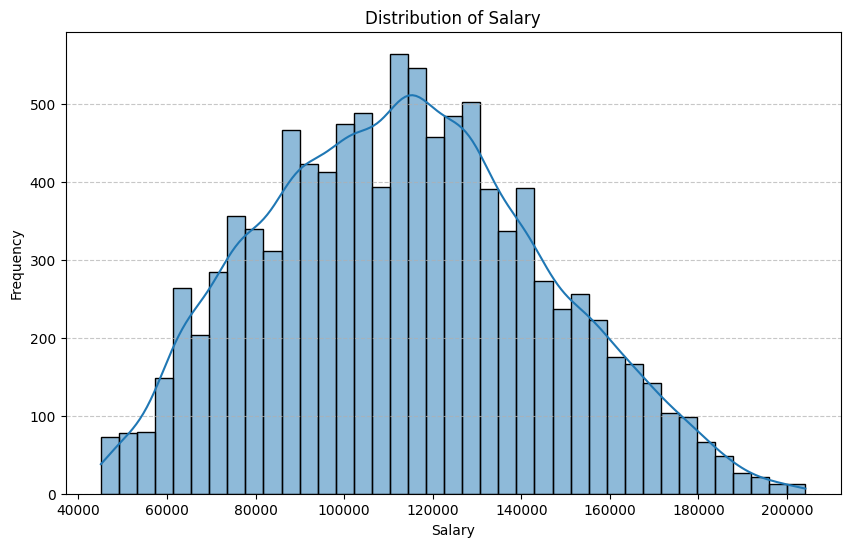

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['salary'], kde=True)
plt.title('Distribution of Salary')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

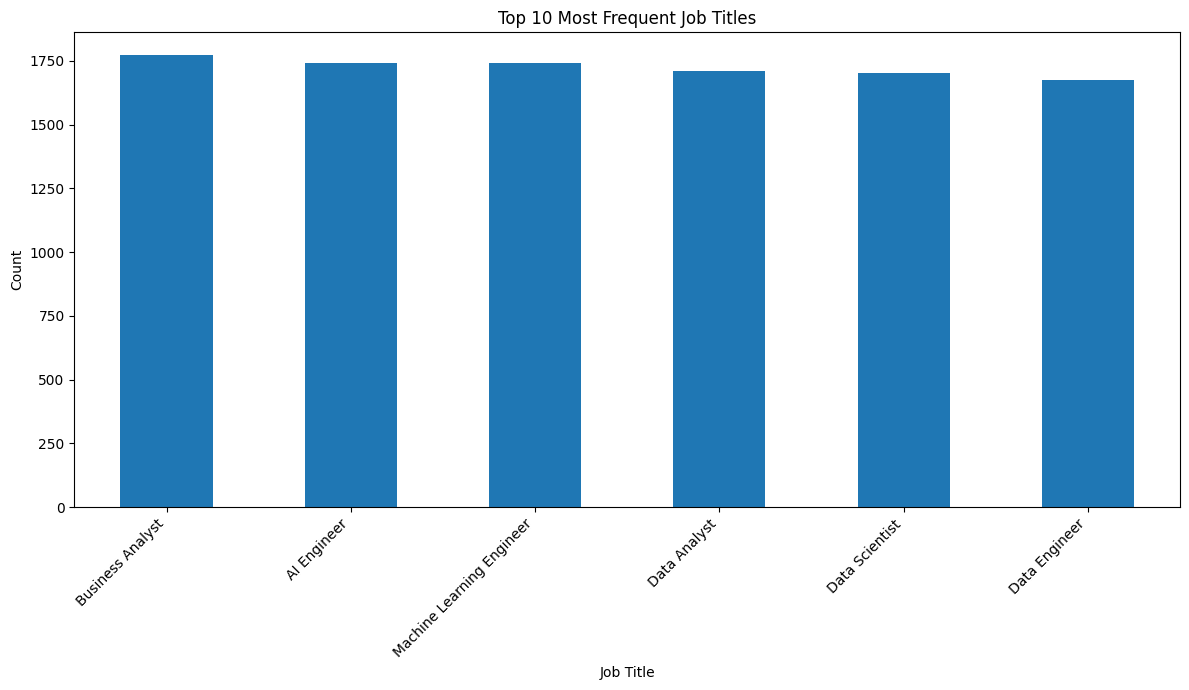

In [ ]:
plt.figure(figsize=(12, 7))
df['job_title'].value_counts().nlargest(10).plot(kind='bar')
plt.title('Top 10 Most Frequent Job Titles')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3427/3664401895.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='experience_level', y='salary', data=df, palette='viridis')


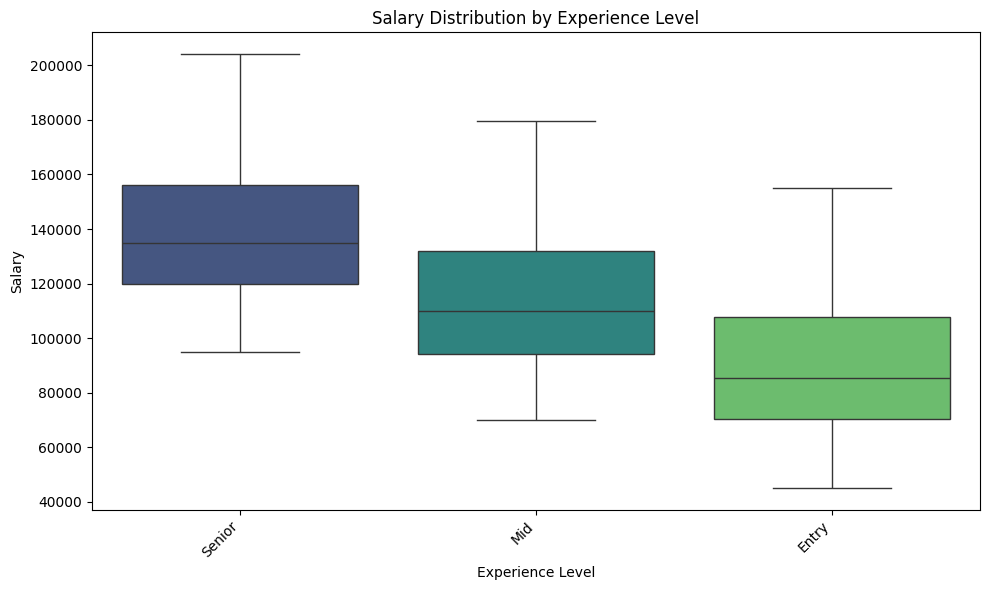

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='experience_level', y='salary', data=df, palette='viridis')
plt.title('Salary Distribution by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

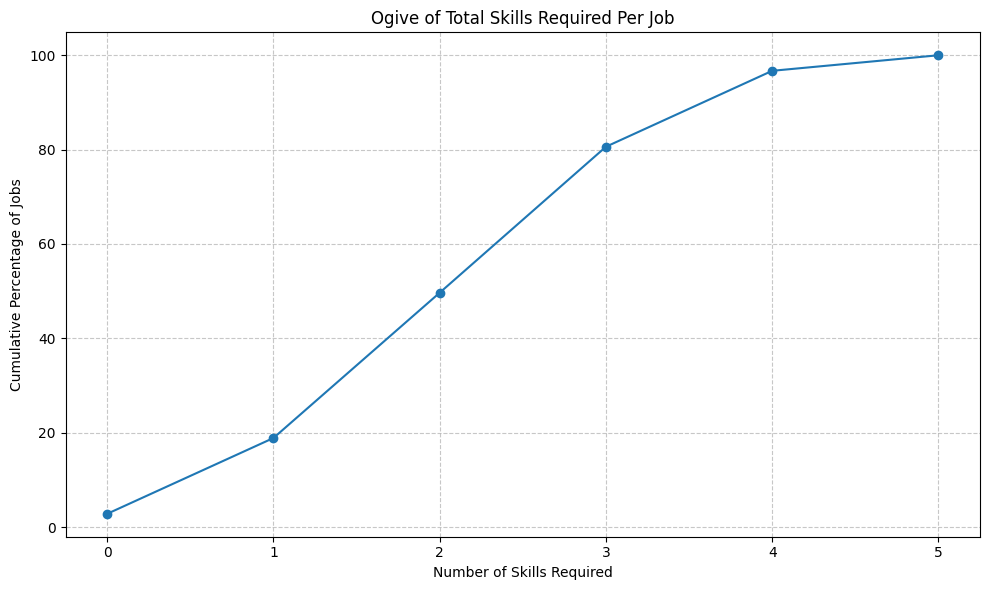

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the skill columns
skill_columns = ['skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']

# Calculate the total number of skills for each job
df['total_skills'] = df[skill_columns].sum(axis=1)

# Calculate the frequency distribution of total_skills
skill_counts = df['total_skills'].value_counts().sort_index().reset_index()
skill_counts.columns = ['Number of Skills', 'Frequency']

# Calculate cumulative frequency and cumulative percentage
skill_counts['Cumulative Frequency'] = skill_counts['Frequency'].cumsum()
skill_counts['Cumulative Percentage'] = (skill_counts['Cumulative Frequency'] / skill_counts['Frequency'].sum()) * 100

# Plot the Ogive
plt.figure(figsize=(10, 6))
plt.plot(skill_counts['Number of Skills'], skill_counts['Cumulative Percentage'], marker='o', linestyle='-')
plt.title('Ogive of Total Skills Required Per Job')
plt.xlabel('Number of Skills Required')
plt.ylabel('Cumulative Percentage of Jobs')
plt.xticks(skill_counts['Number of Skills'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

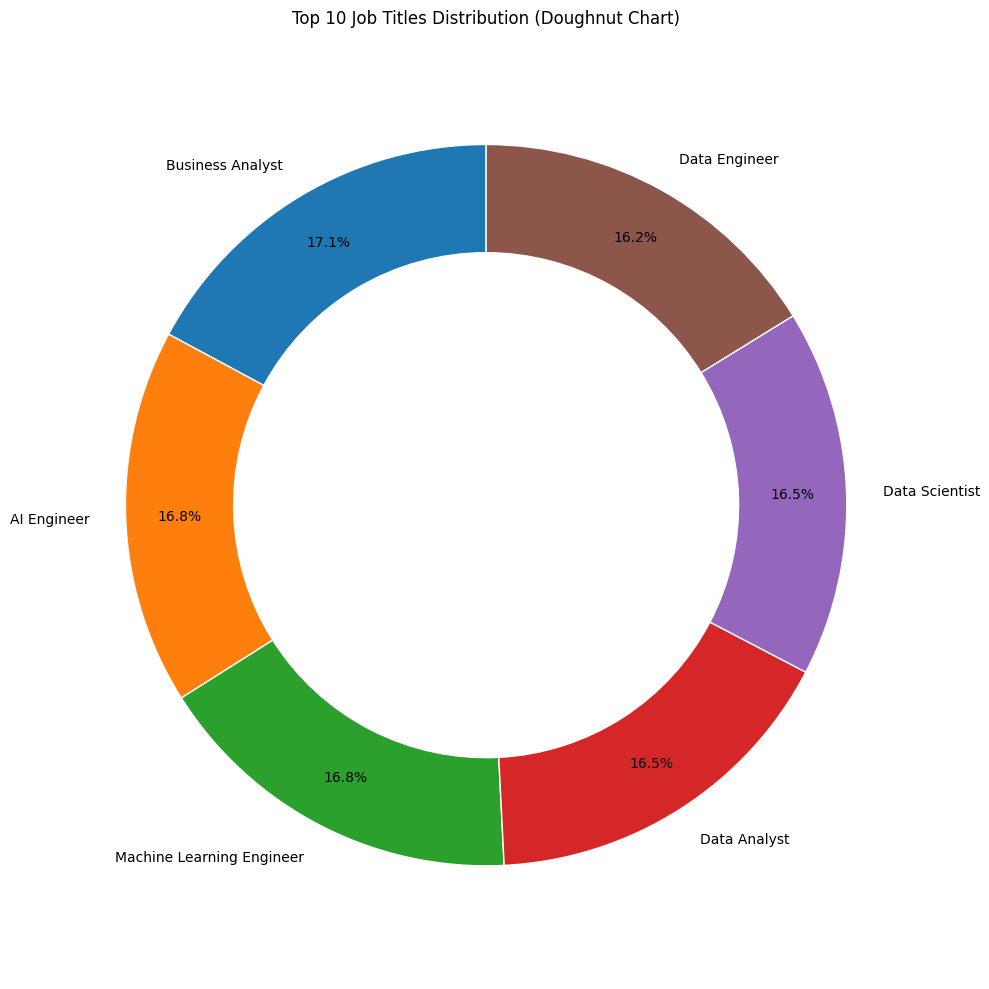

In [ ]:
import matplotlib.pyplot as plt

# Get the top 10 most frequent job titles and their counts
top_job_titles = df['job_title'].value_counts().nlargest(10)

plt.figure(figsize=(10, 10))

# Create the pie chart
plt.pie(top_job_titles, labels=top_job_titles.index, autopct='%1.1f%%', startangle=90, pctdistance=0.85, wedgeprops=dict(width=0.3, edgecolor='w'))

# Draw a white circle in the center to create the doughnut effect
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Top 10 Job Titles Distribution (Doughnut Chart)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

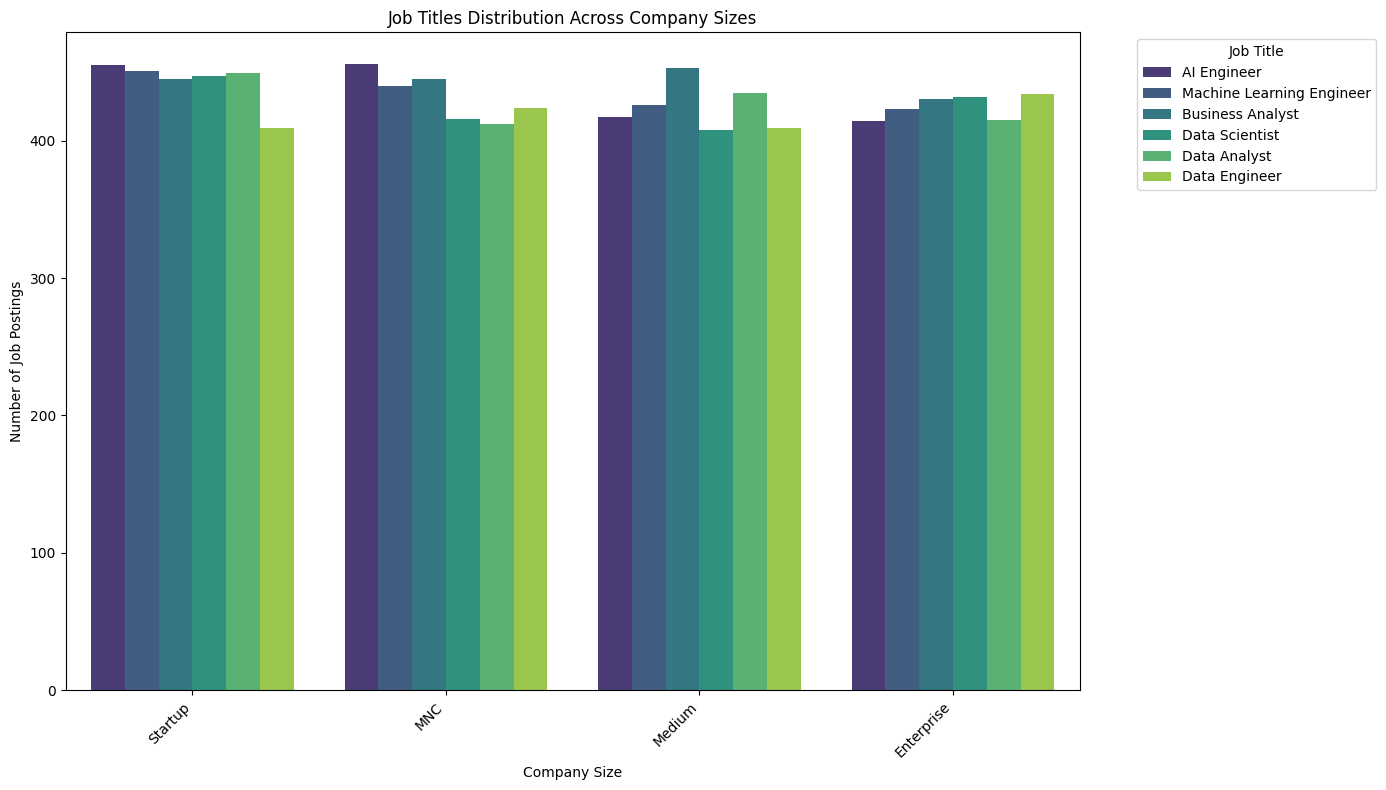

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.countplot(data=df, x='company_size', hue='job_title', palette='viridis', order=df['company_size'].value_counts().index)
plt.title('Job Titles Distribution Across Company Sizes')
plt.xlabel('Company Size')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Job Title', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

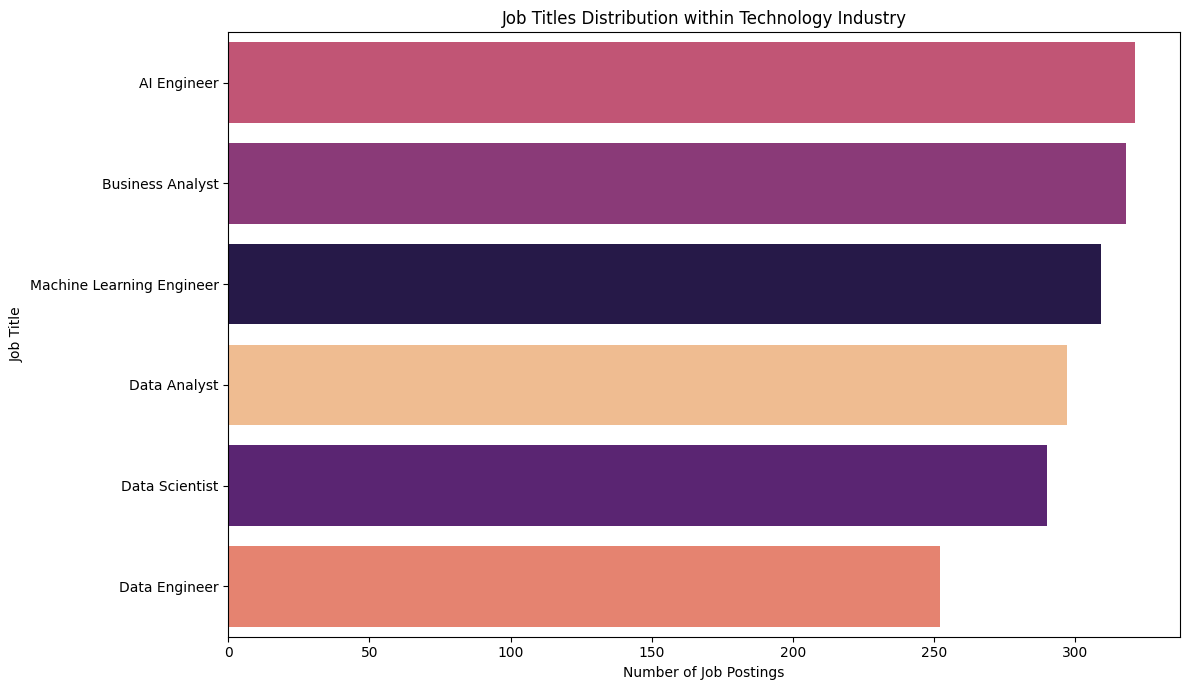

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame for the 'Technology' industry
technology_df = df[df['company_industry'] == 'Technology']

plt.figure(figsize=(12, 7))
sns.countplot(data=technology_df, y='job_title', order=technology_df['job_title'].value_counts().index, palette='magma', hue='job_title', legend=False)
plt.title('Job Titles Distribution within Technology Industry')
plt.xlabel('Number of Job Postings')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3538/1761537917.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='company_size', y='salary', data=df, palette='viridis')


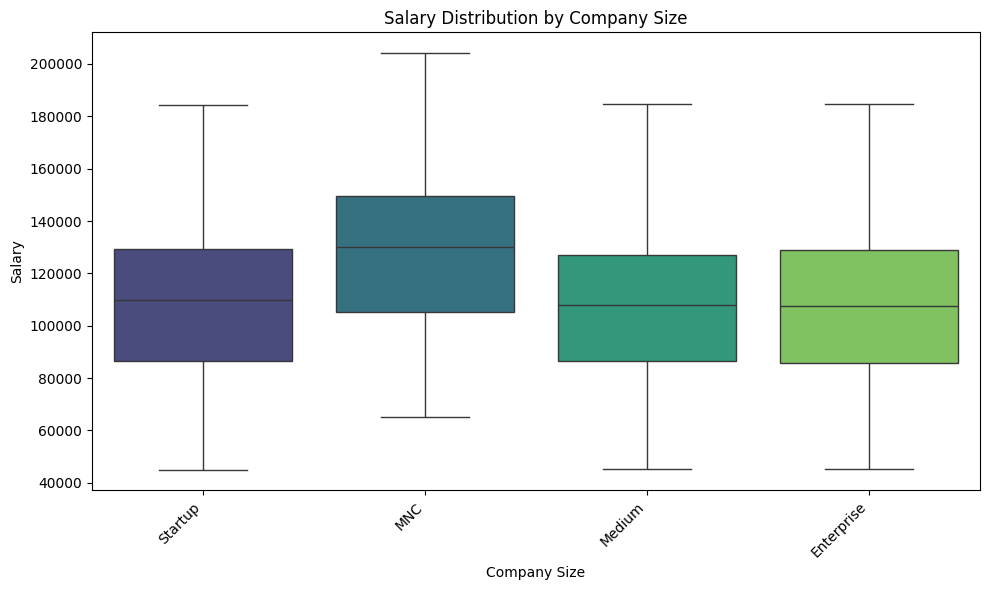

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='company_size', y='salary', data=df, palette='viridis')
plt.title('Salary Distribution by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Salary')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()